<center>

# *Exploratory Data Analysis*

</center>

## Import packages

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_from_disk
import warnings
warnings.filterwarnings('ignore')

Load dataset

In [10]:
ds = load_from_disk('../data/raw')

In [11]:
ds

DatasetDict({
    train: Dataset({
        features: ['words', 'tags'],
        num_rows: 5027
    })
    validation: Dataset({
        features: ['words', 'tags'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['words', 'tags'],
        num_rows: 2000
    })
})

In [12]:
ds_train = ds['train']

Explore sample data

In [13]:
sample = ds_train[0]
print(f"Words : {sample['words']}")
print(f"NER Tags : {sample['tags']}")
print(f"Number of words : {len(sample['words'])}")

Words : ['Đồng', 'thời', ',', 'bệnh', 'viện', 'tiếp', 'tục', 'thực', 'hiện', 'các', 'biện', 'pháp', 'phòng', 'chống', 'dịch', 'bệnh', 'COVID', '-', '19', 'theo', 'hướng', 'dẫn', 'của', 'Bộ', 'Y', 'tế', '.']
NER Tags : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORGANIZATION', 'I-ORGANIZATION', 'I-ORGANIZATION', 'O']
Number of words : 27


Get all label unique

In [16]:
all_tags = []
for example in ds_train:
    all_tags.extend(example['tags'])

# Get unique labels
label_names = sorted(list(set(all_tags)))
print(f"\n🏷️  Total unique labels: {len(label_names)}")
print("\nLabel Names:")
print("-" * 50)
for idx, label in enumerate(label_names):
    print(f"  {idx:2d}: {label}")


🏷️  Total unique labels: 21

Label Names:
--------------------------------------------------
   0: B-AGE
   1: B-DATE
   2: B-GENDER
   3: B-JOB
   4: B-LOCATION
   5: B-NAME
   6: B-ORGANIZATION
   7: B-PATIENT_ID
   8: B-SYMPTOM_AND_DISEASE
   9: B-TRANSPORTATION
  10: I-AGE
  11: I-DATE
  12: I-GENDER
  13: I-JOB
  14: I-LOCATION
  15: I-NAME
  16: I-ORGANIZATION
  17: I-PATIENT_ID
  18: I-SYMPTOM_AND_DISEASE
  19: I-TRANSPORTATION
  20: O


Label distribution analysis

In [17]:
label_counts = Counter(all_tags)
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
for label, count in sorted_labels:
    percentage = count / len(all_tags) * 100
    print(f"{label:<30} {count:>10,} {percentage:>11.2f}%")

print(f"\n{'Total':<30} {len(all_tags):>10,} {100.0:>11.2f}%")

O                                 129,379       77.22%
I-LOCATION                         12,309        7.35%
B-LOCATION                          5,398        3.22%
I-ORGANIZATION                      4,818        2.88%
B-PATIENT_ID                        3,240        1.93%
B-DATE                              2,549        1.52%
I-DATE                              2,500        1.49%
I-SYMPTOM_AND_DISEASE               2,270        1.35%
B-SYMPTOM_AND_DISEASE               1,439        0.86%
B-ORGANIZATION                      1,137        0.68%
B-AGE                                 682        0.41%
B-GENDER                              542        0.32%
B-NAME                                349        0.21%
I-JOB                                 318        0.19%
B-TRANSPORTATION                      226        0.13%
B-JOB                                 205        0.12%
I-NAME                                 80        0.05%
I-TRANSPORTATION                       69        0.04%
I-PATIENT_

Visualize

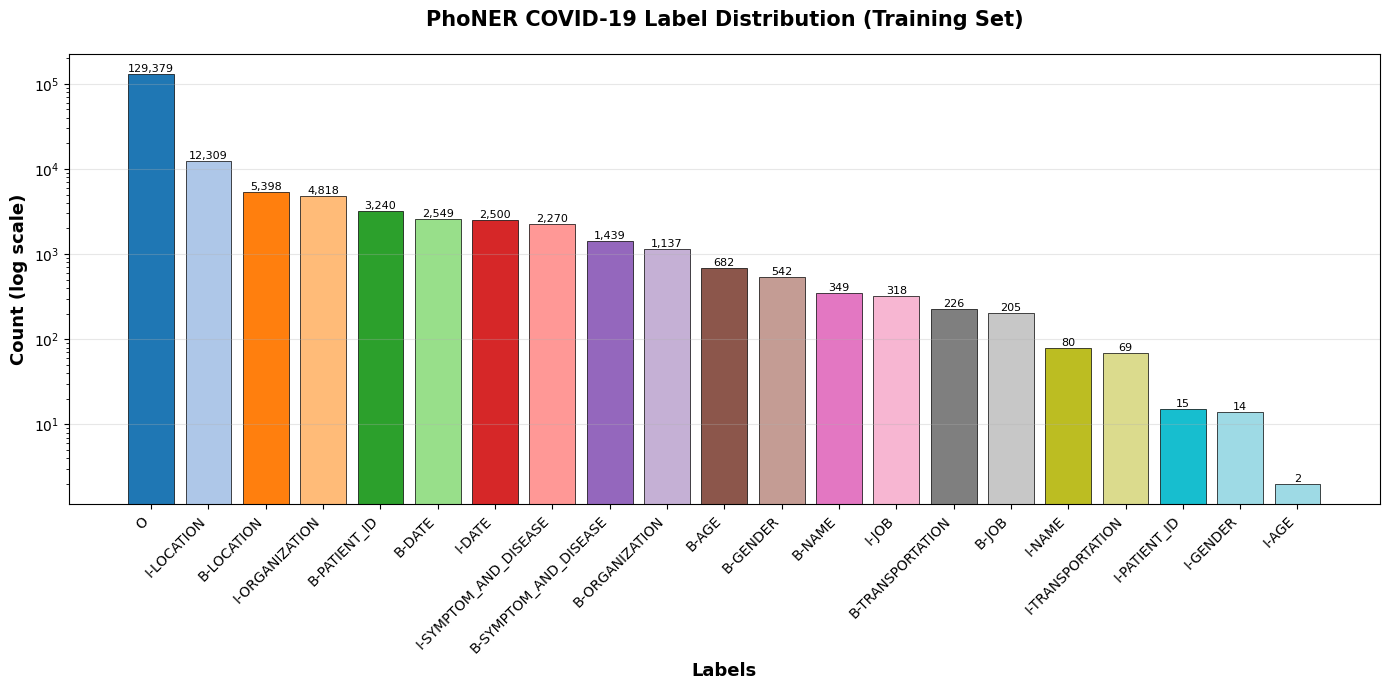

In [18]:
plt.figure(figsize=(14, 7))

labels_list = [label for label, _ in sorted_labels]
counts_list = [count for _, count in sorted_labels]
colors = plt.cm.tab20(range(len(labels_list)))

bars = plt.bar(labels_list, counts_list, color=colors, edgecolor='black', linewidth=0.5)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Labels', fontsize=13, fontweight='bold')
plt.ylabel('Count (log scale)', fontsize=13, fontweight='bold')
plt.title('PhoNER COVID-19 Label Distribution (Training Set)', 
          fontsize=15, fontweight='bold', pad=20)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

Entity type analysis

In [19]:
# Group by entity type (combine B- and I- prefixes)
entity_types = {}
for label, count in label_counts.items():
    if label != 'O' and '-' in label:
        prefix, entity_type = label.split('-', 1)
        if entity_type not in entity_types:
            entity_types[entity_type] = 0
        entity_types[entity_type] += count

# Sort by count
sorted_entities = sorted(entity_types.items(), key=lambda x: x[1], reverse=True)

print("Entity Types (B- and I- combined):")
print(f"{'Entity Type':<30} {'Count':>10} {'Percentage':>12}")
total_entities = sum(entity_types.values())
for entity_type, count in sorted_entities:
    percentage = count / total_entities * 100
    print(f"{entity_type:<30} {count:>10,} {percentage:>11.2f}%")

print(f"\n{'Total':<30} {total_entities:>10,} {100.0:>11.2f}%")

Entity Types (B- and I- combined):
Entity Type                         Count   Percentage
LOCATION                           17,707       46.40%
ORGANIZATION                        5,955       15.60%
DATE                                5,049       13.23%
SYMPTOM_AND_DISEASE                 3,709        9.72%
PATIENT_ID                          3,255        8.53%
AGE                                   684        1.79%
GENDER                                556        1.46%
JOB                                   523        1.37%
NAME                                  429        1.12%
TRANSPORTATION                        295        0.77%

Total                              38,162      100.00%


Visualize

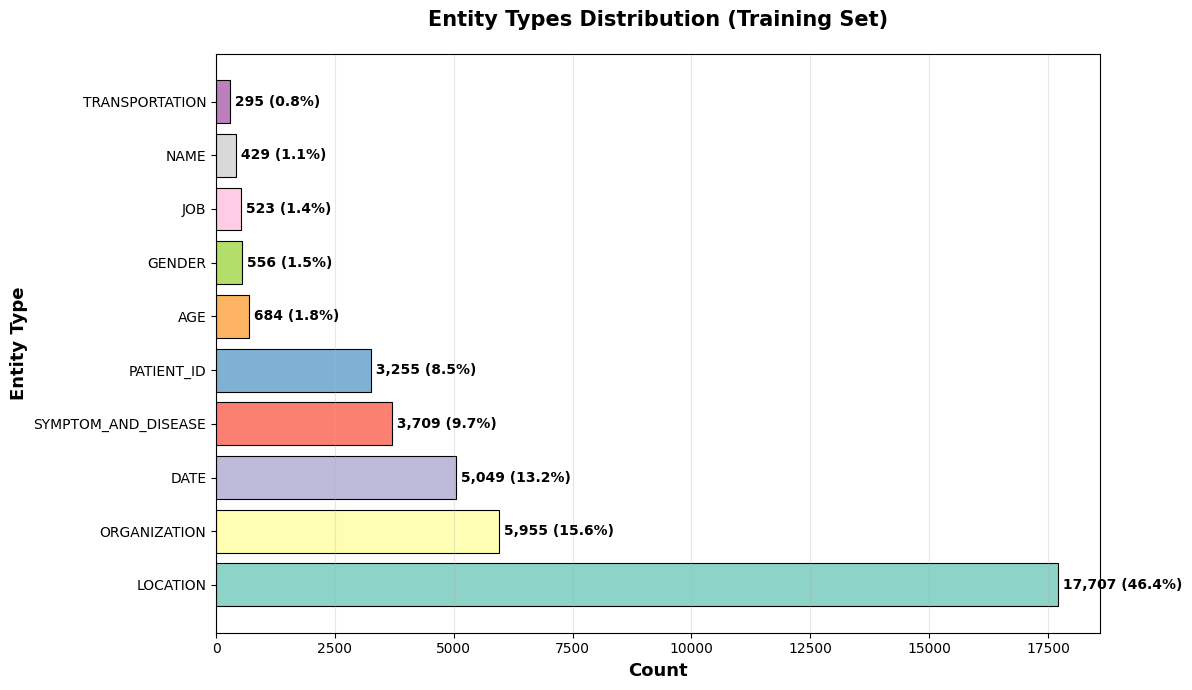

In [20]:
plt.figure(figsize=(12, 7))
types = [e for e, _ in sorted_entities]
type_counts = [c for _, c in sorted_entities]
colors_entities = plt.cm.Set3(range(len(types)))

bars = plt.barh(types, type_counts, color=colors_entities, edgecolor='black', linewidth=0.8)
plt.xlabel('Count', fontsize=13, fontweight='bold')
plt.ylabel('Entity Type', fontsize=13, fontweight='bold')
plt.title('Entity Types Distribution (Training Set)', 
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f' {int(width):,} ({type_counts[i]/total_entities*100:.1f}%)',
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
sentence_lengths = [len(example['words']) for example in ds_train]
stats = {
    'Mean': np.mean(sentence_lengths),
    'Median': np.median(sentence_lengths),
    'Std Dev': np.std(sentence_lengths),
    'Min': np.min(sentence_lengths),
    'Max': np.max(sentence_lengths),
    'Q1 (25%)': np.percentile(sentence_lengths, 25),
    'Q3 (75%)': np.percentile(sentence_lengths, 75),
}
for stat_name, value in stats.items():
    print(f"{stat_name:<15}: {value:>8.2f}")



Mean           :    33.33
Median         :    30.00
Std Dev        :    15.78
Min            :     7.00
Max            :   186.00
Q1 (25%)       :    22.00
Q3 (75%)       :    41.00


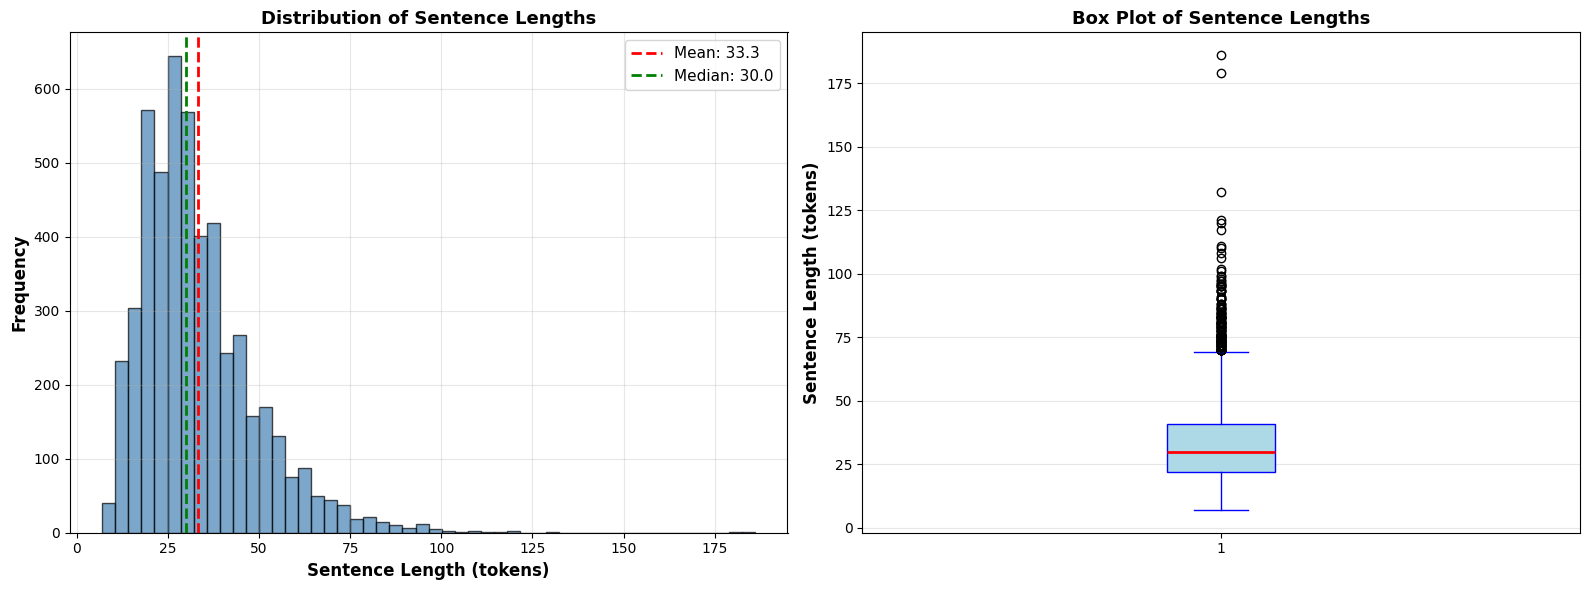

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(sentence_lengths, bins=50, edgecolor='black', 
             alpha=0.7, color='steelblue')
axes[0].axvline(stats['Mean'], color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {stats['Mean']:.1f}")
axes[0].axvline(stats['Median'], color='green', linestyle='--', 
                linewidth=2, label=f"Median: {stats['Median']:.1f}")
axes[0].set_xlabel('Sentence Length (tokens)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Sentence Lengths', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(sentence_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'))
axes[1].set_ylabel('Sentence Length (tokens)', fontsize=12, fontweight='bold')
axes[1].set_title('Box Plot of Sentence Lengths', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Class imbalance Analysis**

In [23]:
o_count = label_counts.get('O', 0)
entity_count = sum([count for label, count in label_counts.items() if label != 'O'])
total = o_count + entity_count
print(f"\nClass Distribution:")
print("-" * 60)
print(f"{'Class':<30} {'Count':>12} {'Percentage':>12}")
print("-" * 60)
print(f"{'O (Non-entity)':<30} {o_count:>12,} {o_count/total*100:>11.2f}%")
print(f"{'Entity tags (B-, I-)':<30} {entity_count:>12,} {entity_count/total*100:>11.2f}%")
print("-" * 60)
print(f"{'Total':<30} {total:>12,} {100.0:>11.2f}%")



Class Distribution:
------------------------------------------------------------
Class                                 Count   Percentage
------------------------------------------------------------
O (Non-entity)                      129,379       77.22%
Entity tags (B-, I-)                 38,162       22.78%
------------------------------------------------------------
Total                               167,541      100.00%


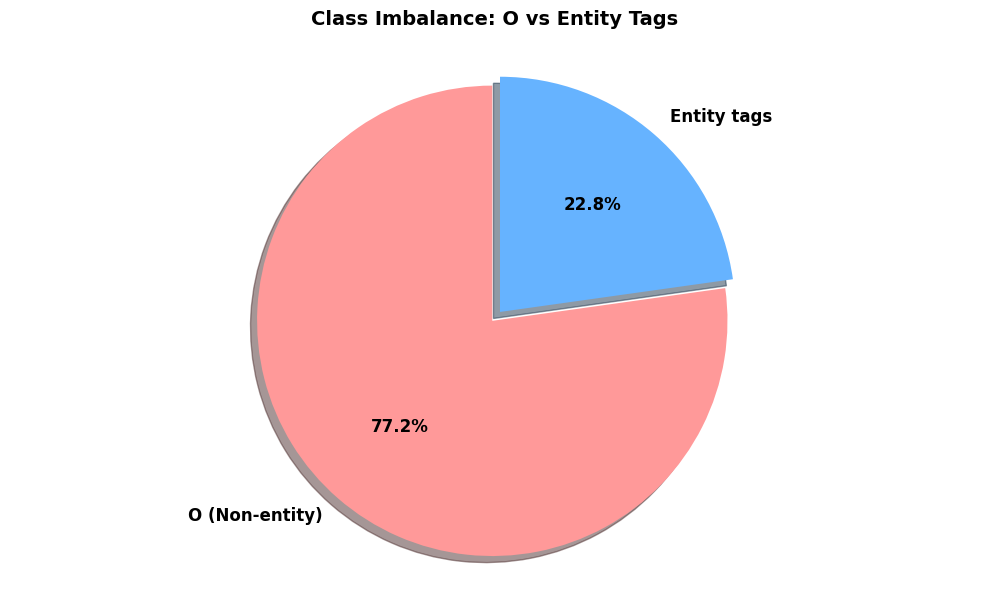

In [24]:
plt.figure(figsize=(10, 6))
classes = ['O (Non-entity)', 'Entity tags']
counts = [o_count, entity_count]
colors_pie = ['#ff9999', '#66b3ff']
explode = (0.05, 0)

plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90,
        colors=colors_pie, explode=explode, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Class Imbalance: O vs Entity Tags', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [25]:
def highlight_entities(words, tags):
    """Print sentence with entities highlighted"""
    result = []
    
    for word, tag in zip(words, tags):
        if tag == 'O':
            result.append(word)
        else:
            result.append(f"[{word}|{tag}]")
    
    return ' '.join(result)

In [26]:
for i in range(10):
    example = ds_train[i]
    highlighted = highlight_entities(example['words'], example['tags'])
    print(f"\n{i+1}. {highlighted}")



1. Đồng thời , bệnh viện tiếp tục thực hiện các biện pháp phòng chống dịch bệnh COVID - 19 theo hướng dẫn của [Bộ|B-ORGANIZATION] [Y|I-ORGANIZATION] [tế|I-ORGANIZATION] .

2. " Số bệnh viện có thể tiếp nhận bệnh nhân bị [sốt|B-SYMPTOM_AND_DISEASE] [cao|I-SYMPTOM_AND_DISEASE] và [khó|B-SYMPTOM_AND_DISEASE] [thở|I-SYMPTOM_AND_DISEASE] đang giảm dần " , thông cáo có đoạn , cảnh báo những bệnh nhân này thay vào đó được chuyển tới các phòng khám khẩn cấp , khiến những bệnh nhân mắc bệnh hiểm nghèo khác không có cơ hội được điều trị .

3. Ngoài ra , những người tiếp xúc gián tiếp ( đã gặp những người tiếp xúc gần với bệnh nhân ) được lập danh sách và yêu cầu cách ly y tế tại nơi ở .

4. Bà này khi trở về quá cảnh [Doha|B-LOCATION] ( [Qatar|B-LOCATION] ) , đáp xuống [Tân|B-LOCATION] [Sơn|I-LOCATION] [Nhất|I-LOCATION] sáng [2/3|B-DATE] cùng 75 hành khách , trong đó có 55 người nước ngoài .

5. " Bệnh nhân [523|B-PATIENT_ID] " và chồng là " bệnh nhân [522|B-PATIENT_ID] " , [67|B-AGE] tuổi , đư

Dataset splits comparison


Splits Statistics:
--------------------------------------------------------------------------------
            Samples  Total Tokens  Total Entities  Avg Sentence Length  Entity Density
train        5027.0      167541.0         38162.0            33.328228        0.227777
validation   2000.0       71325.0         19611.0            35.662500        0.274953
test         2000.0       71325.0         19611.0            35.662500        0.274953


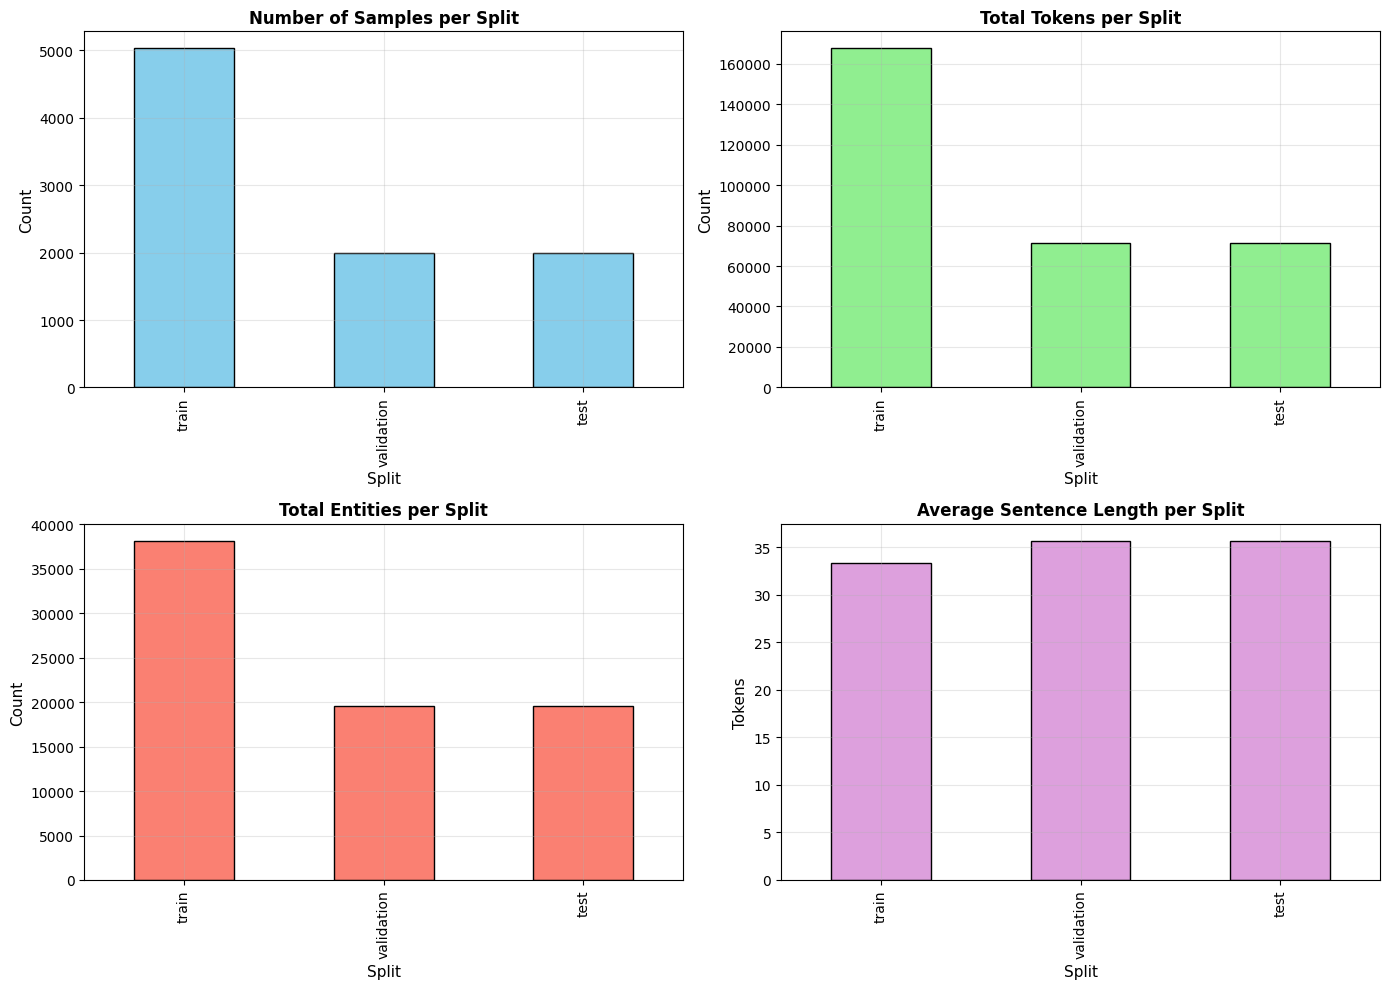

In [27]:
splits_stats = {}
for split_name in ['train', 'validation', 'test']:
    split_data = ds[split_name]
    
    # Calculate statistics
    total_tokens = sum(len(ex['words']) for ex in split_data)
    total_entities = sum(sum(1 for tag in ex['tags'] if tag != 'O') 
                         for ex in split_data)
    avg_length = total_tokens / len(split_data) if len(split_data) > 0 else 0
    
    splits_stats[split_name] = {
        'Samples': len(split_data),
        'Total Tokens': total_tokens,
        'Total Entities': total_entities,
        'Avg Sentence Length': avg_length,
        'Entity Density': total_entities / total_tokens if total_tokens > 0 else 0
    }

# Create DataFrame
df_splits = pd.DataFrame(splits_stats).T

print("\nSplits Statistics:")
print("-" * 80)
print(df_splits.to_string())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Samples comparison
df_splits['Samples'].plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Number of Samples per Split', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_xlabel('Split', fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Total tokens
df_splits['Total Tokens'].plot(kind='bar', ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Total Tokens per Split', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_xlabel('Split', fontsize=11)
axes[0, 1].grid(alpha=0.3)

# Total entities
df_splits['Total Entities'].plot(kind='bar', ax=axes[1, 0], color='salmon', edgecolor='black')
axes[1, 0].set_title('Total Entities per Split', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_xlabel('Split', fontsize=11)
axes[1, 0].grid(alpha=0.3)

# Average sentence length
df_splits['Avg Sentence Length'].plot(kind='bar', ax=axes[1, 1], color='plum', edgecolor='black')
axes[1, 1].set_title('Average Sentence Length per Split', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tokens', fontsize=11)
axes[1, 1].set_xlabel('Split', fontsize=11)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Summary**

In [28]:

summary = {
    'dataset_name': 'PhoNER_COVID19',
    'splits': {
        'train': len(ds['train']),
        'validation': len(ds['validation']),
        'test': len(ds['test'])
    },
    'labels': {
        'total_unique': len(label_names),
        'label_names': label_names,
        'entity_types': list(entity_types.keys())
    },
    'statistics': {
        'total_tokens': len(all_tags),
        'entity_tokens': entity_count,
        'non_entity_tokens': o_count,
        'imbalance_ratio': float((o_count) / entity_count),
        'avg_sentence_length': float(stats['Mean']),
        'max_sentence_length': int(stats['Max'])
    },
    'entity_distribution': {k: int(v) for k, v in entity_types.items()}
}



In [29]:
summary

{'dataset_name': 'PhoNER_COVID19',
 'splits': {'train': 5027, 'validation': 2000, 'test': 2000},
 'labels': {'total_unique': 21,
  'label_names': ['B-AGE',
   'B-DATE',
   'B-GENDER',
   'B-JOB',
   'B-LOCATION',
   'B-NAME',
   'B-ORGANIZATION',
   'B-PATIENT_ID',
   'B-SYMPTOM_AND_DISEASE',
   'B-TRANSPORTATION',
   'I-AGE',
   'I-DATE',
   'I-GENDER',
   'I-JOB',
   'I-LOCATION',
   'I-NAME',
   'I-ORGANIZATION',
   'I-PATIENT_ID',
   'I-SYMPTOM_AND_DISEASE',
   'I-TRANSPORTATION',
   'O'],
  'entity_types': ['ORGANIZATION',
   'SYMPTOM_AND_DISEASE',
   'LOCATION',
   'DATE',
   'PATIENT_ID',
   'AGE',
   'NAME',
   'JOB',
   'TRANSPORTATION',
   'GENDER']},
 'statistics': {'total_tokens': 167541,
  'entity_tokens': 38162,
  'non_entity_tokens': 129379,
  'imbalance_ratio': 3.3902573240396205,
  'avg_sentence_length': 33.328227571115974,
  'max_sentence_length': 186},
 'entity_distribution': {'ORGANIZATION': 5955,
  'SYMPTOM_AND_DISEASE': 3709,
  'LOCATION': 17707,
  'DATE': 5049,
 